In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host=os.environ.get('DB_HOST', os.environ.get('POSTGRES_HOST', 'localhost')),
    port=os.environ.get('DB_PORT', os.environ.get('POSTGRES_PORT', '5432')),
    user=os.environ.get('DB_USER', os.environ.get('POSTGRES_USER', 'postgres')),
    password=os.environ.get('DB_PASSWORD', os.environ.get('POSTGRES_PASSWORD', 'postgres')),
    dbname=os.environ.get('DB_NAME', os.environ.get('POSTGRES_DB', 'olist'))
)

with open('../../sql/analysis/05_payment_type_behavior.sql', 'r') as f:
    sql_script = f.read()

queries = [q + ';' for q in sql_script.split(';') if q.strip()]

df1 = pd.read_sql(queries[0], conn)
df2 = pd.read_sql(queries[1], conn)

display(df1)
display(df2)

/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66208/3766610175.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66208/3766610175.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(queries[1], conn)


,payment_type,total_orders_used,total_payment_value,avg_transaction_value,avg_installments
0,credit_card,76505,12542084.19,163.319021,3.507155
1,boleto,19784,2869361.27,145.034435,1.000000
2,voucher,3866,379436.87,65.703354,1.000000
3,debit_card,1528,217989.79,142.570170,1.000000
4,not_defined,3,0.00,0.000000,1.000000


,payment_type,total_orders,canceled_orders,cancellation_rate_pct
0,voucher,3866,94,2.43
1,credit_card,76505,444,0.58
2,boleto,19784,95,0.48
3,debit_card,1528,7,0.46


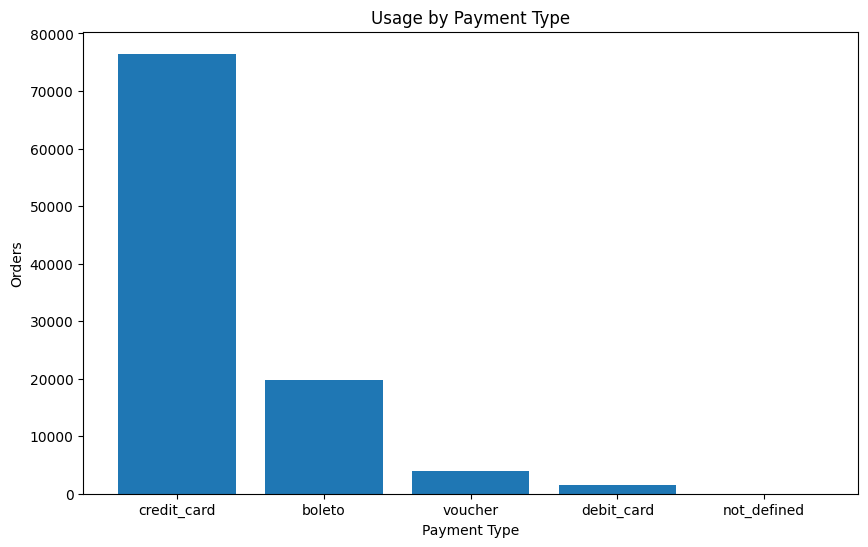

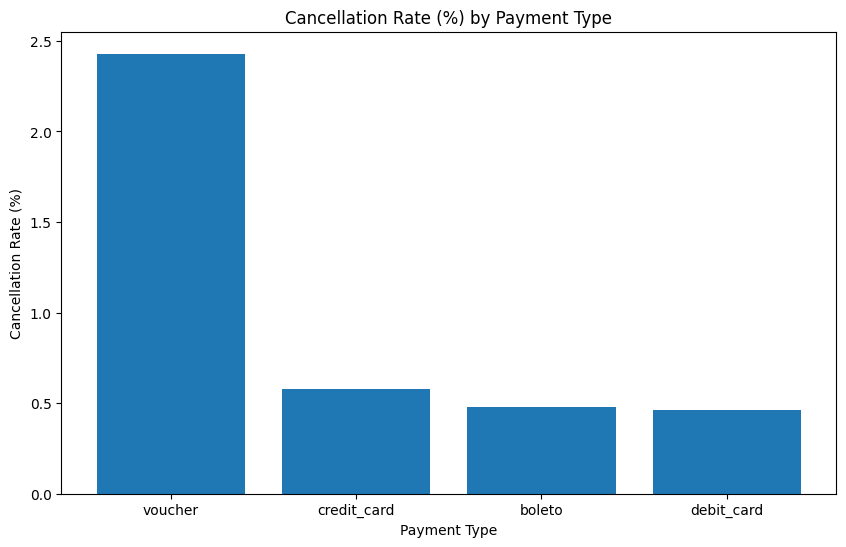

In [2]:
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(df1['payment_type'], df1['total_orders_used'])
ax1.set_title('Usage by Payment Type')
ax1.set_xlabel('Payment Type')
ax1.set_ylabel('Orders')
fig1.savefig('../figures/05_payment_usage.png', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(df2['payment_type'], df2['cancellation_rate_pct'])
ax2.set_title('Cancellation Rate (%) by Payment Type')
ax2.set_xlabel('Payment Type')
ax2.set_ylabel('Cancellation Rate (%)')
fig2.savefig('../figures/05_payment_cancellation.png', bbox_inches='tight')
plt.show()

### Key Findings
- Credit cards are overwhelmingly the most popular payment method.
- Vouchers (Boleto) show uniquely prominent cancellation rate behaviors.